Dataset Shape: (1000, 14)

Missing Values per column:
 image_name                     0
description                    0
embedding                      0
viewer_feelings                0
description_embedding          0
viewer_feelings_embedding      0
image_id                       0
emotion                        0
brightness                     1
colorfulness                  24
facial_expression            888
object                       487
human_action                 886
scene                        788
dtype: int64


C:\Users\gilad\AppData\Local\Temp\ipykernel_24396\3599839130.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




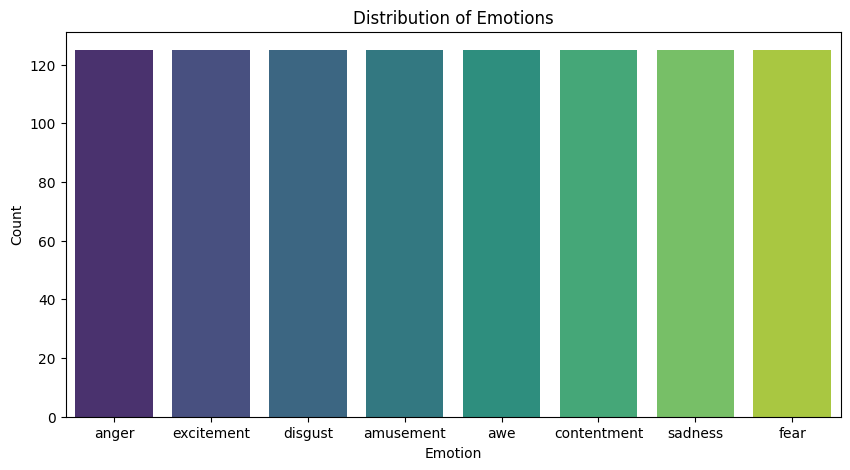

C:\Users\gilad\AppData\Local\Temp\ipykernel_24396\3599839130.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\gilad\AppData\Local\Temp\ipykernel_24396\3599839130.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




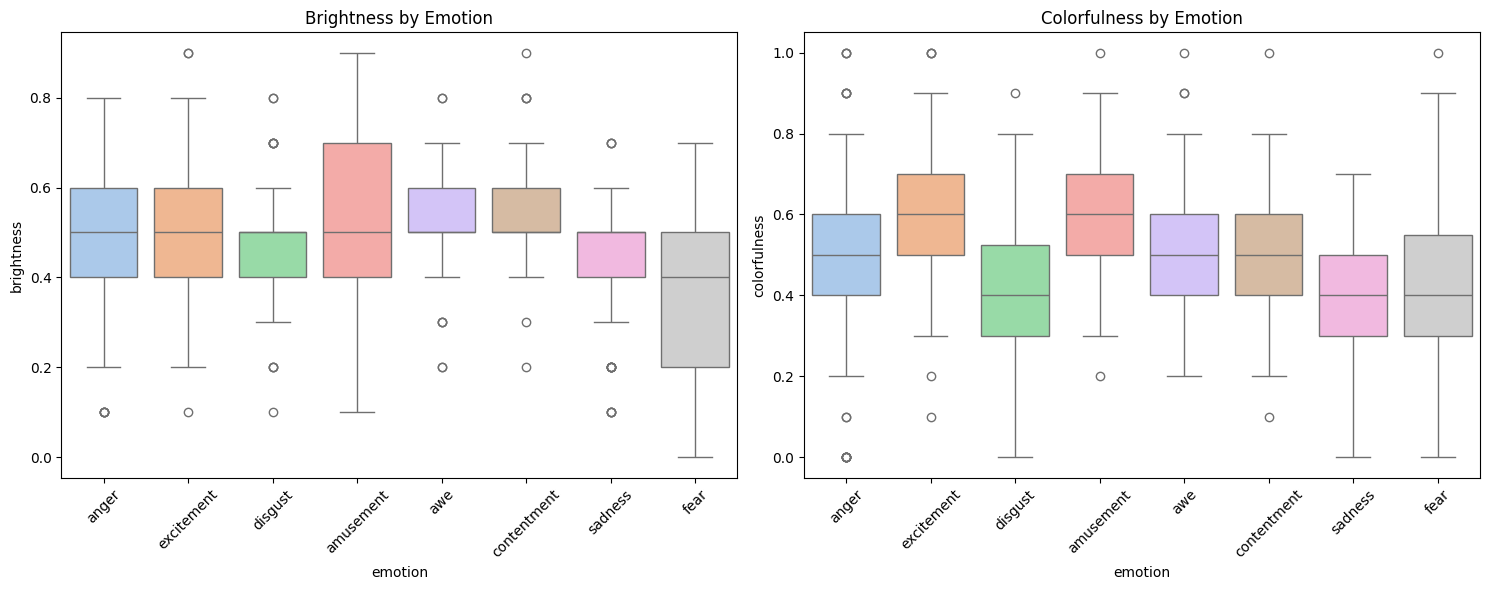

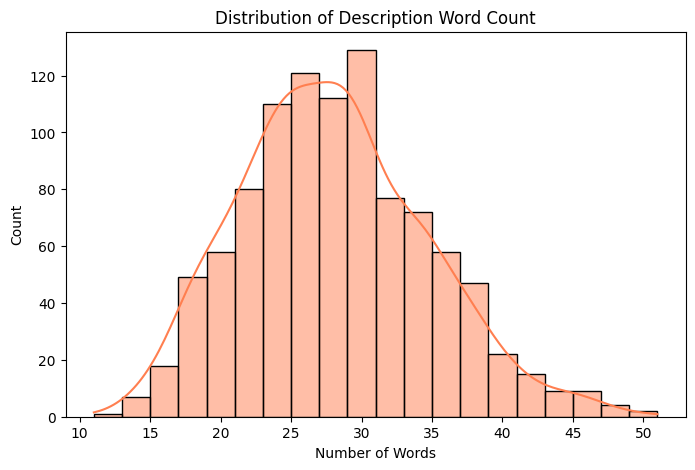

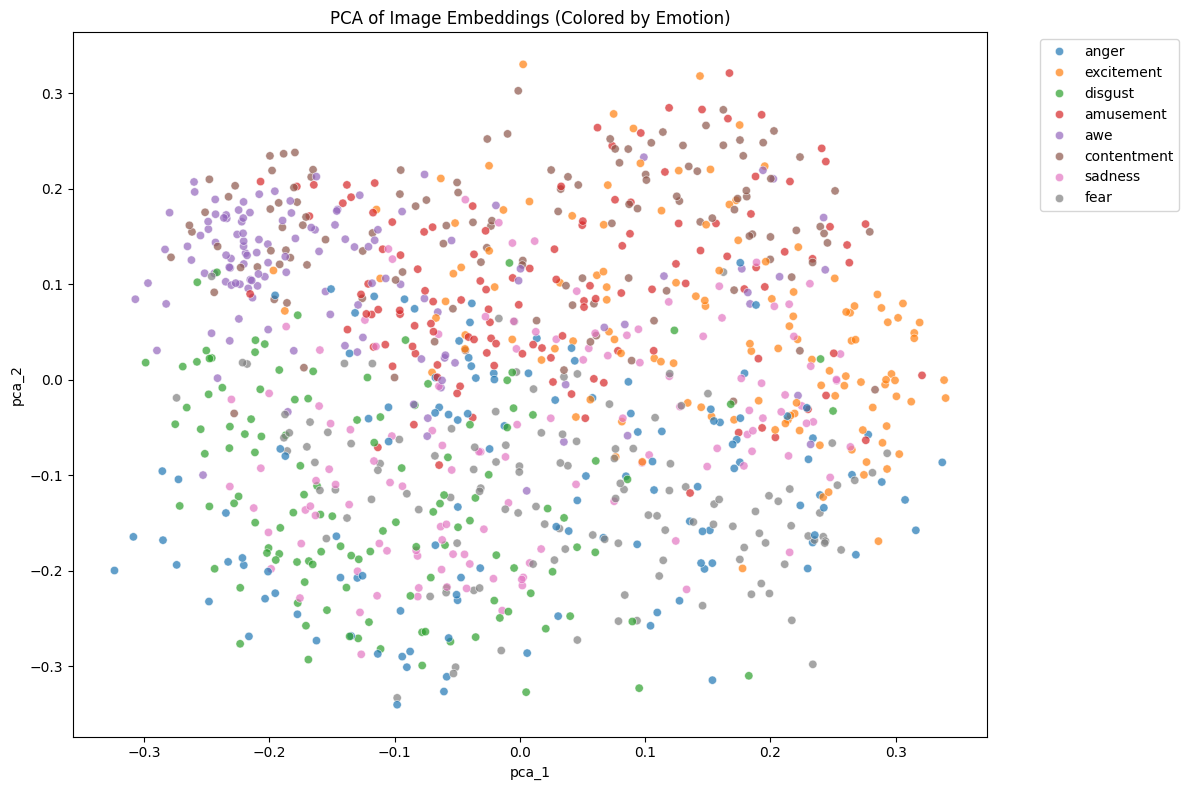

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ---------------------------------------------------------
# Load JSON data
with open('emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# json_normalize flattens nested dictionaries (e.g., 'annotations.emotion' becomes a column)
df = pd.json_normalize(data)

# Clean up column names for easier access
df.rename(columns=lambda x: x.replace('annotations.', ''), inplace=True)

print("Dataset Shape:", df.shape)
print("\nMissing Values per column:\n", df.isnull().sum())

# ---------------------------------------------------------
# 2. UNIVARIATE ANALYSIS
# ---------------------------------------------------------
# Target Variable Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='viridis')
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

# ---------------------------------------------------------
# 3. BIVARIATE ANALYSIS (Tabular Features vs Target)
# ---------------------------------------------------------
# Brightness and Colorfulness across different emotions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='emotion', y='brightness', ax=axes[0], palette='pastel')
axes[0].set_title('Brightness by Emotion')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='emotion', y='colorfulness', ax=axes[1], palette='pastel')
axes[1].set_title('Colorfulness by Emotion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. TEXT ANALYSIS
# ---------------------------------------------------------
# Look at the length of descriptions to understand our text feature volume
df['desc_word_count'] = df['description'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.histplot(df['desc_word_count'], bins=20, kde=True, color='coral')
plt.title('Distribution of Description Word Count')
plt.xlabel('Number of Words')
plt.show()

# ---------------------------------------------------------
# 5. DIMENSIONALITY REDUCTION (Image Embeddings)
# ---------------------------------------------------------
# Extract the list of embeddings into a 2D numpy array
image_embeddings = np.array(df['embedding'].tolist())

# Apply PCA to reduce thousands of dimensions to 2
pca = PCA(n_components=2)
pca_result = pca.fit_transform(image_embeddings)

df['pca_1'] = pca_result[:, 0]
df['pca_2'] = pca_result[:, 1]

# Scatter plot of the reduced embeddings, colored by emotion
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='pca_1', 
    y='pca_2', 
    hue='emotion', 
    palette='tab10', 
    alpha=0.7
)
plt.title('PCA of Image Embeddings (Colored by Emotion)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
pip install "nbformat>=4.2.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Principal Component Analysis (PCA)
We use PCA to project high-dimensional image embeddings into a 3D linear space, allowing us to visualize the global structure and quantify the variance captured by the primary axes.

In [23]:
import pandas as pd
import numpy as np
import json
from sklearn.decomposition import PCA
import plotly.express as px

# 1. Load Data (Remembering the utf-8 encoding!)
with open('emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

df = pd.json_normalize(data)
df.rename(columns=lambda x: x.replace('annotations.', ''), inplace=True)

# 2. Extract the embeddings
image_embeddings = np.array(df['embedding'].tolist())

# 3. Apply PCA, but this time with 3 components
pca = PCA(n_components=3)
pca_result_3 = pca.fit_transform(image_embeddings)

# 4. Add the 3 dimensions back to the dataframe
df['pca_1'] = pca_result_3[:, 0]
df['pca_2'] = pca_result_3[:, 1]
df['pca_3'] = pca_result_3[:, 2]

# 5. Create the interactive 3D scatter plot
fig = px.scatter_3d(
    df, 
    x='pca_1', 
    y='pca_2', 
    z='pca_3',
    color='emotion',             # Colors points by emotion
    hover_name='image_name',     # Shows the image name when you hover over a dot
    hover_data=['brightness', 'colorfulness'], # Adds extra info to the tooltip
    title='Interactive 3D PCA of Image Embeddings',
    opacity=0.7                  # Makes dots slightly transparent to see overlaps
)

# Optional: Adjust the size of the dots for better visibility
fig.update_traces(marker=dict(size=4))

# 6. Show the plot (This will open an interactive widget in your notebook)
fig.show()

# NOTE: If you want to share this plot with your project partner, 
# you can save it as an interactive webpage!
# fig.write_html("interactive_3d_pca.html")

In [18]:
# To see the variance explained by each of the 3 dimensions:
print("Variance explained by each PC:", pca.explained_variance_ratio_)

# To see the total variance captured by your 3D plot:
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Variance explained by each PC: [0.05433639 0.04291371 0.04215012]
Total variance explained: 0.13940021763175492


To understand the global structure of the image embeddings, we applied PCA. We found that the first three principal components explain only $\sim 14 \%$ of the total variance. This indicates that the embeding dataset is highly complex and multi-dimensional; a simple linear projection is insufficient to capture the nuance of the emotional features. This justifies our decision to move toward more complex non-linear models later in the project.

#### Uniform Manifold Approximation and Projection (UMAP)
We apply UMAP to identify non-linear clusters within the embeddings, preserving local relationships between similar images to evaluate how effectively the data naturally groups by emotion.

In [24]:
import pandas as pd
import numpy as np
import json
import plotly.express as px
import umap  # Make sure to pip install umap-learn

# 1. Load Data (with utf-8 encoding)
with open('emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

df = pd.json_normalize(data)
df.rename(columns=lambda x: x.replace('annotations.', ''), inplace=True)

# 2. Extract the embeddings
image_embeddings = np.array(df['embedding'].tolist())

# 3. Apply UMAP to reduce dimensions to 3
# random_state ensures you get the exact same plot every time you run it
umap_3d = umap.UMAP(n_components=3, random_state=42, init='random')
umap_result_3 = umap_3d.fit_transform(image_embeddings)

# 4. Add the 3 dimensions back to the dataframe
df['umap_1'] = umap_result_3[:, 0]
df['umap_2'] = umap_result_3[:, 1]
df['umap_3'] = umap_result_3[:, 2]

# 5. Create the interactive 3D scatter plot
fig = px.scatter_3d(
    df, 
    x='umap_1', 
    y='umap_2', 
    z='umap_3',
    color='emotion',             # Colors points by emotion
    hover_name='image_name',     # Shows the image name when you hover over a dot
    hover_data=['brightness', 'colorfulness'], # Adds extra info to the tooltip
    title='Interactive 3D UMAP of Image Embeddings',
    opacity=0.7                  # Makes dots slightly transparent
)

# Adjust the size of the dots for better visibility
fig.update_traces(marker=dict(size=4))

# 6. Save the plot as an interactive webpage (Bypasses the Jupyter show() error)
fig.write_html("interactive_3d_umap.html", auto_open=True)

# If you installed nbformat>=4.2.0 and restarted your kernel, you can also uncomment this:
# fig.show()

c:\Users\gilad\Documents\GitHub\Embeddings\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [25]:
from sklearn.metrics import silhouette_score

# Assuming pca_result and umap_result are your 3D arrays from earlier, 
# and df['emotion'] are your labels:
pca_score = silhouette_score(pca_result_3, df['emotion'])
umap_score = silhouette_score(umap_result_3, df['emotion'])

print(f"PCA Silhouette Score: {pca_score:.4f}")
print(f"UMAP Silhouette Score: {umap_score:.4f}")

PCA Silhouette Score: -0.0171
UMAP Silhouette Score: -0.0092


Our Silhouette analysis yielded scores near zero for both PCA and UMAP. In the context of Visual Emotion Analysis, this is expected. Human emotions are a spectrum rather than isolated categories. Images labeled as 'Fear' often share visual characteristics (darkness, facial tension) with images labeled as 'Sadness.' The near-zero score mathematically confirms the high degree of class overlap and the subjective nature of the labels in this dataset.

In [20]:
import pandas as pd
import numpy as np
import json
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import umap # Make sure umap-learn is installed

# 1. Load Data
with open('emoset_challenge_1000_augmented.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

df = pd.json_normalize(data)
df.rename(columns=lambda x: x.replace('annotations.', ''), inplace=True)

# 2. Extract embeddings and true labels
image_embeddings = np.array(df['embedding'].tolist())
true_labels = df['emotion']
n_emotions = len(df['emotion'].unique()) # Should be 8

# 3. Apply PCA and UMAP
pca_result = PCA(n_components=3, random_state=42).fit_transform(image_embeddings)
umap_result = umap.UMAP(n_components=3, random_state=42).fit_transform(image_embeddings)

# 4. Apply K-Means Clustering to the PCA and UMAP results
# We look for K=8 clusters because we have 8 true emotions
kmeans = KMeans(n_clusters=n_emotions, random_state=42, n_init=10)
pca_predicted_clusters = kmeans.fit_predict(pca_result)

umap_predicted_clusters = kmeans.fit_predict(umap_result)

# 5. Calculate Metrics for PCA
pca_homog = homogeneity_score(true_labels, pca_predicted_clusters)
pca_comp = completeness_score(true_labels, pca_predicted_clusters)
pca_v_score = v_measure_score(true_labels, pca_predicted_clusters)

# 6. Calculate Metrics for UMAP
umap_homog = homogeneity_score(true_labels, umap_predicted_clusters)
umap_comp = completeness_score(true_labels, umap_predicted_clusters)
umap_v_score = v_measure_score(true_labels, umap_predicted_clusters)

# 7. Print Results
print("--- PCA Clustering Performance ---")
print(f"Homogeneity:  {pca_homog:.4f}")
print(f"Completeness: {pca_comp:.4f}")
print(f"V-measure:    {pca_v_score:.4f}\n")

print("--- UMAP Clustering Performance ---")
print(f"Homogeneity:  {umap_homog:.4f}")
print(f"Completeness: {umap_comp:.4f}")
print(f"V-measure:    {umap_v_score:.4f}")

c:\Users\gilad\Documents\GitHub\Embeddings\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



--- PCA Clustering Performance ---
Homogeneity:  0.2776
Completeness: 0.2800
V-measure:    0.2788

--- UMAP Clustering Performance ---
Homogeneity:  0.3477
Completeness: 0.3522
V-measure:    0.3499


We evaluated the effectiveness of dimensionality reduction by running K-Means clustering ($k=8$) on the reduced spaces. UMAP significantly outperformed PCA across all clustering metrics (V-measure: $0.35$ vs $0.28$). This suggests that the relationship between image embeddings and emotions is non-linear. UMAP's ability to preserve local manifold structures allowed it to capture the 'emotional clusters' more effectively than PCA's linear approach.